# 4. Анализ цен и маржинальности

## Цели:
- Анализ распределения маржинальности
- Выявление проблемных товаров
- Анализ цен по брендам и категориям
- Рекомендации по оптимизации ценовой политики

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')

# %%
# Настройка путей
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.pricing_analyzer import PricingAnalyzer

In [2]:
# Загрузка данных
print("ЗАГРУЗКА ДАННЫХ ДЛЯ АНАЛИЗА ЦЕН...")
processed_data_path = project_root / 'data' / 'processed' / 'merged_data.csv'

if processed_data_path.exists():
    df = pd.read_csv(processed_data_path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    print(f"Загружено {len(df)} записей")
    
    # Проверяем наличие ключевых колонок
    required_cols = ['margin', 'revenue', 'profit']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"⚠ Отсутствуют колонки: {missing_cols}")
else:
    print("❌ Файл с обработанными данными не найден")

ЗАГРУЗКА ДАННЫХ ДЛЯ АНАЛИЗА ЦЕН...
Загружено 2366 записей


In [3]:
# Инициализация анализатора
print("ИНИЦИАЛИЗАЦИЯ АНАЛИЗАТОРА ЦЕН...")
try:
    pricing_analyzer = PricingAnalyzer(df)
    print("✅ Анализатор успешно инициализирован")
except Exception as e:
    print(f"❌ Ошибка инициализации анализатора: {e}")

ИНИЦИАЛИЗАЦИЯ АНАЛИЗАТОРА ЦЕН...
✅ Анализатор успешно инициализирован


In [4]:
# 1. АНАЛИЗ РАСПРЕДЕЛЕНИЯ МАРЖИ
print("\n" + "="*60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ МАРЖИНАЛЬНОСТИ")
print("="*60)

margin_analysis = pricing_analyzer.analyze_margin_distribution()

if margin_analysis:
    print("\nОбщая статистика по марже:")
    print(margin_analysis['overall_stats'])
    
    print("\nРаспределение по сегментам маржи:")
    print(margin_analysis['segment_stats'])
else:
    print("Нет данных для анализа маржи")


АНАЛИЗ РАСПРЕДЕЛЕНИЯ МАРЖИНАЛЬНОСТИ

Общая статистика по марже:
count    2366.000000
mean        0.727104
std         0.415189
min        -1.000000
25%         0.249651
50%         1.000000
75%         1.000000
max         1.000000
Name: margin, dtype: float64

Распределение по сегментам маржи:
                    sku  revenue       profit  order_id  revenue_share  \
margin_segment                                                           
Сильно убыточные     45    67560    -15667.10        56            0.6   
Убыточные            96   388529    -14406.97       101            3.3   
Низкомаржинальные   188  1130494     57059.96       213            9.7   
Среднемаржинальные  161  1096767    160461.17       177            9.4   
Высокомаржинальные   46   291592     65310.00        47            2.5   
Сверхмаржинальные   788  8735781  15610521.21      1757           74.6   

                    profit_share  
margin_segment                    
Сильно убыточные            -0.1  
Убыто

In [5]:
# 2. АНАЛИЗ ЦЕН ПО КАТЕГОРИЯМ И БРЕНДАМ
print("\n" + "="*60)
print("АНАЛИЗ ЦЕН И МАРЖИ ПО КАТЕГОРИЯМ И БРЕНДАМ")
print("="*60)

category_analysis = pricing_analyzer.analyze_pricing_by_categories()

if 'by_brand' in category_analysis:
    print("\nТоп-10 брендов по выручке с маржей:")
    top_brands = category_analysis['by_brand'].head(10)
    print(top_brands[['revenue', 'profit', 'avg_margin', 'current_price', 'sku']].to_string())
    
if 'by_category' in category_analysis:
    print("\nКатегории по выручке с маржей:")
    print(category_analysis['by_category'][['revenue', 'profit', 'avg_margin', 'current_price', 'sku']].to_string())


АНАЛИЗ ЦЕН И МАРЖИ ПО КАТЕГОРИЯМ И БРЕНДАМ

Топ-10 брендов по выручке с маржей:
            revenue       profit  avg_margin  current_price  sku
Бренд                                                           
KZDOO       8534704  11700898.30       137.1        5515.43  569
KEEPHONE    1743949   2401593.49       137.7        5114.22  128
K-DOO        601024    784534.78       130.5        4387.04   48
Robiton      296250    347191.80       117.2        2194.44   51
Неизвестно   206660    221471.20       107.2       10333.00    7
REMAX        115266    135150.30       117.3        1310.24   24
Нет бренда    76230     93295.20       122.4        2117.50   14
Varta         69420     85162.80       122.7        1596.00    9
Raigor        31080     46201.20       148.7        5180.00    1
Renata        25920     35731.50       137.9        1620.00    6

Категории по выручке с маржей:
                           revenue       profit  avg_margin  current_price  sku
Категория                  

In [6]:
# 3. ВЫЯВЛЕНИЕ ПРОБЛЕМНЫХ ТОВАРОВ
print("\n" + "="*60)
print("ВЫЯВЛЕНИЕ ПРОБЛЕМНЫХ ТОВАРОВ")
print("="*60)

problematic_products = pricing_analyzer.find_problematic_products(margin_threshold=0.05, min_orders=1)

if not problematic_products.empty:
    print(f"Найдено {len(problematic_products)} проблемных товаров с маржой < 5%")
    
    print("\nТоп-15 самых убыточных товаров:")
    top_problematic = problematic_products.head(15)
    print(top_problematic[['sku', 'Бренд', 'Категория', 'margin', 'profit', 'loss_per_order', 'order_id']].to_string(index=False))
    
    # Анализ убыточных товаров
    loss_making = problematic_products[problematic_products['margin'] < 0]
    if not loss_making.empty:
        print(f"\n❌ УБЫТОЧНЫЕ ТОВАРЫ: {len(loss_making)} шт.")
        print(f"Суммарные убытки: {loss_making['profit'].sum():,.0f} ₽")
        print(f"Средние убытки на товар: {loss_making['profit'].mean():.0f} ₽")


ВЫЯВЛЕНИЕ ПРОБЛЕМНЫХ ТОВАРОВ
Найдено 38 проблемных товаров с маржой < 5%

Топ-15 самых убыточных товаров:
           sku      Бренд                Категория    margin  profit  loss_per_order  order_id
 GGG_Blue_2602  Panasonic Батарейки и аккумуляторы -0.871000  -499.5         -249.75         2
 HHH_Pink_8731    Robiton Батарейки и аккумуляторы -0.704286  -394.4         -394.40         1
EEE_Black_2674  Panasonic Батарейки и аккумуляторы -0.701667  -213.0         -106.50         2
 AAA_Pink_2206  Panasonic Батарейки и аккумуляторы -0.385238  -161.8         -161.80         1
HHH_White_3457 Нет бренда                    Чехлы -0.160000  -160.0         -160.00         1
 HHH_Blue_7358      KZDOO                    Чехлы -0.154257  -384.1         -384.10         1
  CCC_Red_9477      KZDOO                    Чехлы -0.138387  -429.0         -214.50         2
BBB_Black_9198    Robiton Батарейки и аккумуляторы -0.134375  -473.0         -118.25         4
  DDD_Red_2803    Robiton Батарейки и 

In [7]:
# 4. АНАЛИЗ ЭЛАСТИЧНОСТИ СПРОСА
print("\n" + "="*60)
print("АНАЛИЗ ЭЛАСТИЧНОСТИ СПРОСА ПО ЦЕНЕ")
print("="*60)

elasticity_analysis = pricing_analyzer.analyze_price_elasticity()

if elasticity_analysis:
    print(f"Корреляция цена-количество: {elasticity_analysis['correlation']:.3f}")
    print(f"Оценка эластичности: {elasticity_analysis['elasticity']:.3f}")
    
    print("\nРаспределение товаров по типу эластичности:")
    print(elasticity_analysis['summary'])
    
    # Покажем примеры товаров по типам эластичности
    product_data = elasticity_analysis['product_data']
    for elasticity_type in ['Эластичный', 'Нейтральный', 'Неэластичный']:
        examples = product_data[product_data['elasticity_type'] == elasticity_type].head(3)
        if not examples.empty:
            print(f"\n{elasticity_type} спрос - примеры:")
            print(examples[['sku', 'Бренд', 'current_price', 'quantity']].to_string(index=False))


АНАЛИЗ ЭЛАСТИЧНОСТИ СПРОСА ПО ЦЕНЕ
Корреляция цена-количество: -0.010
Оценка эластичности: -6.759

Распределение товаров по типу эластичности:
elasticity_type
Неэластичный    839
Эластичный        0
Нейтральный       0
Name: count, dtype: int64

Неэластичный спрос - примеры:
           sku    Бренд  current_price  quantity
AAA_Black_1398    K-DOO         2580.0         4
AAA_Black_1577    KZDOO         3180.0         7
AAA_Black_1627 KEEPHONE         7990.0         2


In [8]:
# 5. ОПТИМИЗАЦИЯ ЦЕНОВОЙ ПОЛИТИКИ
print("\n" + "="*60)
print("ОПТИМИЗАЦИЯ ЦЕНОВОЙ ПОЛИТИКИ")
print("="*60)

optimization_recommendations = pricing_analyzer.optimize_pricing_recommendations(target_margin=0.2)

print(f"Текущая средняя маржа: {optimization_recommendations['current_avg_margin']:.1%}")
print(f"Целевая маржа: {optimization_recommendations['target_margin']:.0%}")

print("\nРЕКОМЕНДАЦИИ ПО ОПТИМИЗАЦИИ:")
for i, rec in enumerate(optimization_recommendations['recommendations'], 1):
    impact_icon = '🔴' if rec['impact'] == 'high' else '🟡' if rec['impact'] == 'medium' else '🟢'
    print(f"{i}. {impact_icon} {rec['description']}")
    print(f"   {rec['details']}")
    print()


ОПТИМИЗАЦИЯ ЦЕНОВОЙ ПОЛИТИКИ
Текущая средняя маржа: 72.7%
Целевая маржа: 20%

РЕКОМЕНДАЦИИ ПО ОПТИМИЗАЦИИ:
1. 🔴 Повысить цены на 411 низкомаржинальных товаров
   Текущая маржа: 2.4%, Целевая: 20%

2. 🟡 Снизить цены на 788 высокомаржинальных товаров
   Текущая маржа: 95.9%, Можно снизить до 20%

3. 🔴 Рассмотреть исключение 135 убыточных товаров
   Суммарные убытки: -30,074 ₽




ВИЗУАЛИЗАЦИЯ АНАЛИЗА ЦЕН И МАРЖИ


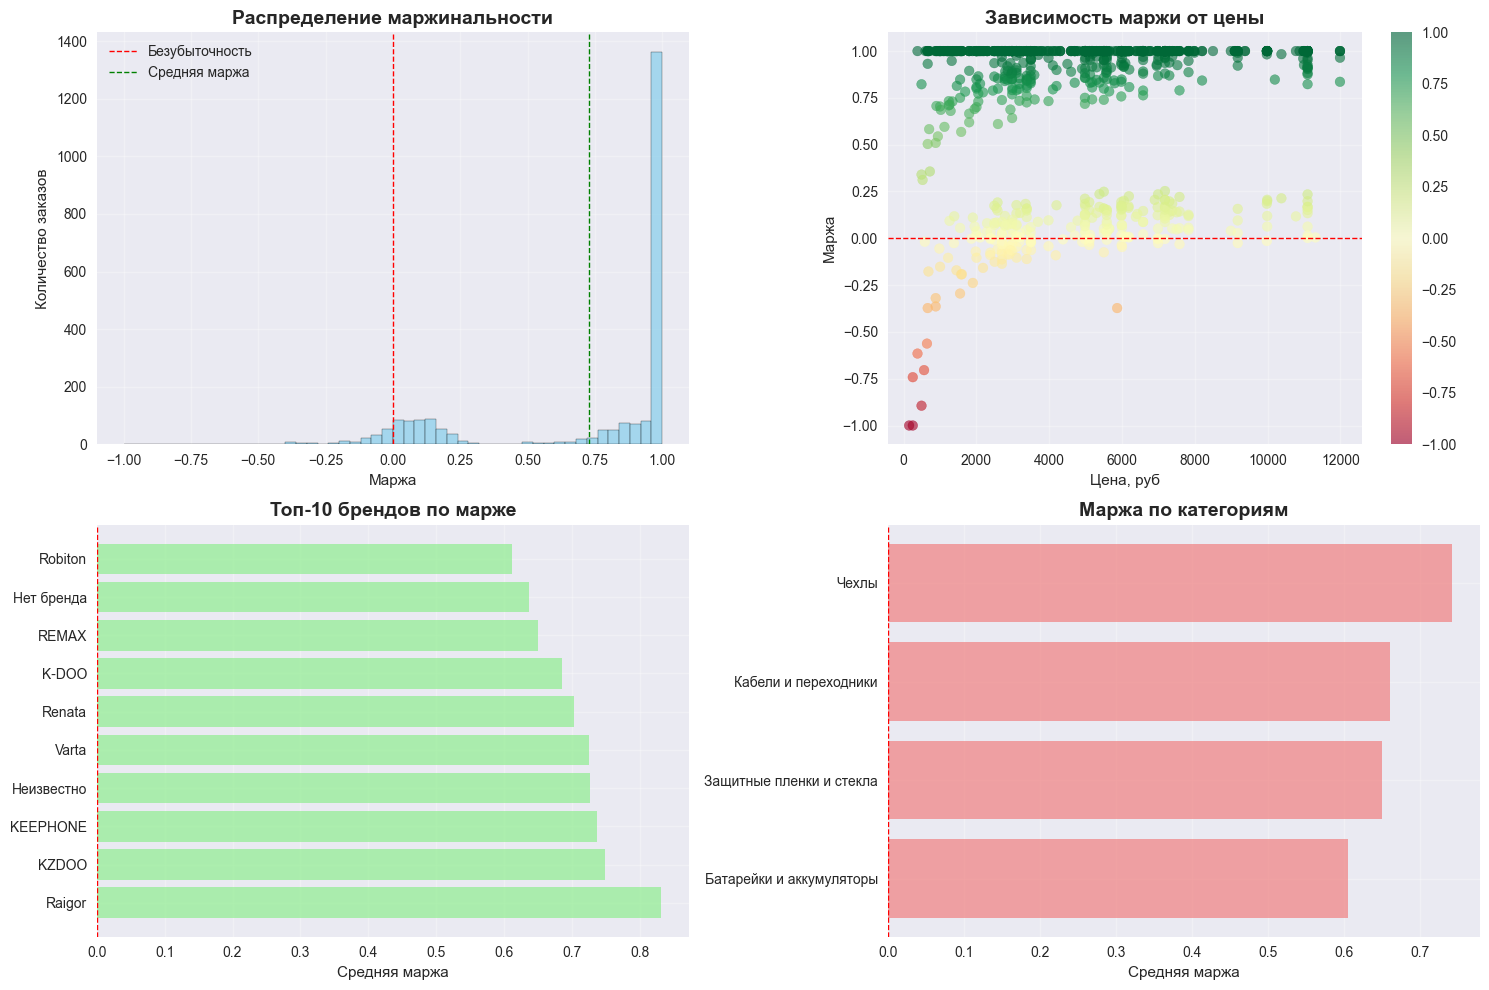


ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ
🚀 ВЫСОКОМАРЖИНАЛЬНЫЕ ТОВАРЫ (>30%): 788 шт.
                          sku  revenue  margin
Категория                                     
Чехлы                     703  8340005   0.966
Батарейки и аккумуляторы   61   301010   0.904
Защитные пленки и стекла   24    89876   0.908
Кабели и переходники        2     4890   0.911

⚠ НИЗКОМАРЖИНАЛЬНЫЕ ТОВАРЫ (0-10%): 188 шт.
                          sku  revenue  margin
Категория                                     
Чехлы                     177  1095764   0.050
Батарейки и аккумуляторы    6    26100   0.066
Защитные пленки и стекла    5     7940   0.035
Кабели и переходники        1      690   0.046


In [9]:
# 6. ВИЗУАЛИЗАЦИЯ АНАЛИЗА
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ АНАЛИЗА ЦЕН И МАРЖИ")
print("="*60)

pricing_analyzer.plot_pricing_analysis()

# %%
# 7. ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ")
print("="*60)

# Анализ высокомаржинальных товаров
high_margin = df[df['margin'] > 0.3]
if not high_margin.empty:
    print(f"🚀 ВЫСОКОМАРЖИНАЛЬНЫЕ ТОВАРЫ (>30%): {high_margin['sku'].nunique()} шт.")
    high_margin_summary = high_margin.groupby('Категория').agg({
        'sku': 'nunique',
        'revenue': 'sum',
        'margin': 'mean'
    }).round(3).sort_values('revenue', ascending=False)
    print(high_margin_summary.head())

# Анализ низкомаржинальных товаров
low_margin = df[df['margin'].between(0, 0.1)]
if not low_margin.empty:
    print(f"\n⚠ НИЗКОМАРЖИНАЛЬНЫЕ ТОВАРЫ (0-10%): {low_margin['sku'].nunique()} шт.")
    low_margin_summary = low_margin.groupby('Категория').agg({
        'sku': 'nunique', 
        'revenue': 'sum',
        'margin': 'mean'
    }).round(3).sort_values('revenue', ascending=False)
    print(low_margin_summary.head())

In [10]:
# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА ЦЕН")
print("="*60)

# Создаем папку для отчетов
pricing_report_path = project_root / 'reports' / 'pricing_analysis'
pricing_report_path.mkdir(parents=True, exist_ok=True)

# Сохраняем результаты
if not problematic_products.empty:
    problematic_products.to_csv(pricing_report_path / 'problematic_products.csv', index=False)
    print("✓ Сохранены проблемные товары")

if category_analysis.get('by_brand') is not None:
    category_analysis['by_brand'].to_csv(pricing_report_path / 'brand_pricing.csv', index=False)
    print("✓ Сохранен анализ по брендам")

if margin_analysis:
    margin_analysis['segment_stats'].to_csv(pricing_report_path / 'margin_segments.csv')
    print("✓ Сохранены сегменты маржи")

# Сохраняем рекомендации
recommendations_df = pd.DataFrame(optimization_recommendations['recommendations'])
recommendations_df.to_csv(pricing_report_path / 'pricing_recommendations.csv', index=False)
print("✓ Сохранены рекомендации по ценам")


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА ЦЕН
✓ Сохранены проблемные товары
✓ Сохранен анализ по брендам
✓ Сохранены сегменты маржи
✓ Сохранены рекомендации по ценам


In [11]:
# 9. ИТОГОВЫЕ ВЫВОДЫ
print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО ЦЕНОВОЙ ПОЛИТИКЕ")
print("="*60)

total_products = df['sku'].nunique()
total_revenue = df['revenue'].sum()
avg_margin = df['margin'].mean()

print(f"📊 ОБЩАЯ СТАТИСТИКА:")
print(f"  • Товаров всего: {total_products}")
print(f"  • Средняя маржа: {avg_margin:.1%}")
print(f"  • Общая выручка: {total_revenue:,.0f} ₽")

if not problematic_products.empty:
    problem_share = len(problematic_products) / total_products * 100
    print(f"\n🎯 ПРОБЛЕМНЫЕ ЗОНЫ:")
    print(f"  • Проблемных товаров: {len(problematic_products)} ({problem_share:.1f}%)")
    print(f"  • Убыточных товаров: {len(problematic_products[problematic_products['margin'] < 0])}")

print(f"\n💡 РЕКОМЕНДАЦИИ:")
print(f"  • Приоритет: {len(optimization_recommendations['recommendations'])} ключевых действий")
print(f"  • Цель: повысить среднюю маржу до {optimization_recommendations['target_margin']:.0%}")

print("\n✅ АНАЛИЗ ЦЕН И МАРЖИ ЗАВЕРШЕН!")
print("📊 Созданы визуализации и рекомендации")
print("📁 Сохранены отчеты в /reports/pricing_analysis/")


ИТОГОВЫЕ ВЫВОДЫ ПО ЦЕНОВОЙ ПОЛИТИКЕ
📊 ОБЩАЯ СТАТИСТИКА:
  • Товаров всего: 859
  • Средняя маржа: 72.7%
  • Общая выручка: 11,710,723 ₽

🎯 ПРОБЛЕМНЫЕ ЗОНЫ:
  • Проблемных товаров: 38 (4.4%)
  • Убыточных товаров: 28

💡 РЕКОМЕНДАЦИИ:
  • Приоритет: 3 ключевых действий
  • Цель: повысить среднюю маржу до 20%

✅ АНАЛИЗ ЦЕН И МАРЖИ ЗАВЕРШЕН!
📊 Созданы визуализации и рекомендации
📁 Сохранены отчеты в /reports/pricing_analysis/
